In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mdtraj as md
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
import pandas as pd

# ---------- 0. 路径 ----------
top_file        = "ref.gro"
PAC5_trj_files  = ["./trj/PAC5_100_1.gro", "./trj/PAC5_100_2.gro", "./trj/PAC5_500.gro"]
RNA_trj_files   = ["./trj/RNA_100_1.gro",  "./trj/RNA_100_2.gro",  "./trj/RNA_500.gro"]
ssDNA_trj_files = ["./trj/ssDNA_100_1.gro","./trj/ssDNA_100_2.gro","./trj/ssDNA_500.gro"]

# ---------- 1. 加载、对齐、截 20 ns、拼接 ----------
def load_and_trim(traj_files, top_file, align_idx, ref, alert=False):
    trj_list   = []
    src_list   = []
    time_list  = []
    for f in traj_files:
        trj = md.load(f, top=top_file)
        trj.superpose(ref, frame=0, atom_indices=align_idx)
        trj  = trj[trj.time >= 20_000]          # 去掉前 20 ns
        trj  = trj.atom_slice(align_idx)        # 只保留对齐原子
        trj_list.append(trj)
        src_list.append(np.full(trj.n_frames, os.path.basename(f)))
        time_list.append(trj.time)              # 保留原始物理时间
        if alert: print(f)
    traj_cat = md.join(trj_list)
    source   = np.concatenate(src_list)
    real_time= np.concatenate(time_list)
    meta_df = pd.DataFrame({
        'Frame': np.arange(traj_cat.n_frames),
        'source': source,
        'time_ps': real_time
    })
    return traj_cat, meta_df

print("> loading")
ref      = md.load(top_file)
align_id = ref.top.select('resSeq 15 to 115')   # 统一对齐+PCA 用重原子

PAC5 , PAC5_meta_df = load_and_trim(PAC5_trj_files,  top_file, align_id, ref)
RNA  , RNA_meta_df = load_and_trim(RNA_trj_files,   top_file, align_id, ref)
ssDNA, ssDNA_meta_df = load_and_trim(ssDNA_trj_files, top_file, align_id, ref)
print("> load done")

# ---------- 2. 统一 PCA ----------
combined = md.join([PAC5, RNA, ssDNA])
pca = PCA(n_components=2)
coords = pca.fit_transform(combined.xyz.reshape(combined.n_frames, -1))

n1, n2  = PAC5.n_frames, RNA.n_frames
pca_PAC5 = coords[:n1]
pca_RNA  = coords[n1:n1+n2]
pca_ssDNA= coords[n1+n2:]
print("> PCA done")

# ---------- 3. Bhattacharyya 系数 ----------
def bhattacharyya_2d(x, y, bw='scott'):
    kde_x = gaussian_kde(x.T, bw_method=bw)
    kde_y = gaussian_kde(y.T, bw_method=bw)
    xmin = min(x[:,0].min(), y[:,0].min()); xmax = max(x[:,0].max(), y[:,0].max())
    ymin = min(x[:,1].min(), y[:,1].min()); ymax = max(x[:,1].max(), y[:,1].max())
    xi,yi = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    grid  = np.vstack([xi.ravel(), yi.ravel()])
    z_x = kde_x(grid).reshape(xi.shape); z_x /= z_x.sum()
    z_y = kde_y(grid).reshape(xi.shape); z_y /= z_y.sum()
    return np.sum(np.sqrt(z_x * z_y))

ov_PR = bhattacharyya_2d(pca_PAC5, pca_RNA)
ov_PS = bhattacharyya_2d(pca_PAC5, pca_ssDNA)
ov_RS = bhattacharyya_2d(pca_RNA,  pca_ssDNA)
CEV   = pca.explained_variance_ratio_.sum()

print(f"> Cumulative explained variance: {CEV*100:.2f}%")
print(f"> PAC5-RNA   overlap: {ov_PR*100:.2f}%")
print(f"> PAC5-ssDNA overlap: {ov_PS*100:.2f}%")
print(f"> RNA-ssDNA  overlap: {ov_RS*100:.2f}%")

> loading
> load done
> PCA done
> Cumulative explained variance: 30.41%
> PAC5-RNA   overlap: 16.12%
> PAC5-ssDNA overlap: 39.26%
> RNA-ssDNA  overlap: 45.16%


In [8]:
import pickle, os

with open('pickle/full_data.pkl', 'wb') as f:
    pickle.dump({
        'trajectories': {'PAC5': PAC5, 'RNA': RNA, 'ssDNA': ssDNA},
        'pca_coords'  : {'PAC5': pca_PAC5, 'RNA': pca_RNA, 'ssDNA': pca_ssDNA},
        'overlap'     : {'PR': ov_PR, 'PS': ov_PS, 'RS': ov_RS, 'CEV': CEV},
        'PCA_ratio'   : (
           round(float(pca.explained_variance_ratio_[0]) * 100, 2),
           round(float(pca.explained_variance_ratio_[1]) * 100, 2)
           )
        }, f)
with open("pickle/meta_df.pkl", "wb") as f:
    pickle.dump({'PAC5' : PAC5_meta_df,
                 'RNA'  : RNA_meta_df,
                 'ssDNA': ssDNA_meta_df}, f)

In [24]:
import pickle

with open('pickle/full_data.pkl', 'rb') as f:
    dat = pickle.load(f)

# 轨迹对象
PAC5  = dat['trajectories']['PAC5']
RNA   = dat['trajectories']['RNA']
ssDNA = dat['trajectories']['ssDNA']

# PCA 坐标
pca_coords = dat['pca_coords']
pca_PAC5   = pca_coords['PAC5']
pca_RNA    = pca_coords['RNA']
pca_ssDNA  = pca_coords['ssDNA']

PCA_ratio = dat["PCA_ratio"]

# 重叠度
overlap = dat['overlap']
ov_PR   = overlap['PR']
ov_PS   = overlap['PS']
ov_RS   = overlap['RS']
CEV     = overlap['CEV']

# 颜色
colors = {'PAC5': 'tab:blue', 'RNA': 'tab:orange', 'ssDNA': 'tab:green'}

with open('pickle/meta_df.pkl', 'rb') as f:
    meta_df = pickle.load(f)
PCA_ratio

(19.63, 10.79)

In [25]:
def kde_peak_coord(pca_xy):
    from scipy.stats import gaussian_kde
    from scipy.spatial import cKDTree
    import numpy as np
    kde = gaussian_kde(pca_xy.T, bw_method='scott')
    xmin, xmax = pca_xy[:, 0].min(), pca_xy[:, 0].max()
    ymin, ymax = pca_xy[:, 1].min(), pca_xy[:, 1].max()
    xi, yi = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    grid = np.vstack([xi.ravel(), yi.ravel()])
    dens = kde(grid).reshape(xi.shape)
    peak_flat = dens.argmax()
    x_peak = float(xi.ravel()[peak_flat])
    y_peak = float(yi.ravel()[peak_flat])
    tree = cKDTree(pca_xy)
    _, frame_idx = tree.query((x_peak, y_peak), k=1)
    return x_peak, y_peak, int(frame_idx)

def pick(traj_pca, cx, cy):
    from scipy.spatial import cKDTree
    dist, idx = cKDTree(traj_pca).query([cx, cy], k=1)
    coord = traj_pca[idx].tolist()   # 原生 list
    return coord[0], coord[1], int(idx)

picked_coords = {
    "RNA"  : kde_peak_coord(pca_RNA),
    "ssDNA": kde_peak_coord(pca_ssDNA),
    "PAC5" : pick(
        pca_PAC5,
        kde_peak_coord(pca_ssDNA)[0],
        kde_peak_coord(pca_ssDNA)[1] - 0.5
        )
}

picked_coords

{'RNA': (5.1673054695129395, 1.7868094444274902, 5345),
 'ssDNA': (-1.5882996320724487, -3.264798641204834, 3438),
 'PAC5': (-1.6447465419769287, -3.769899606704712, 965)}

In [26]:
meta_df["PAC5"].iloc[picked_coords["PAC5"][2]]
pd.concat([meta_df[df_col].iloc[picked_coords[df_col][2]] for df_col in ["PAC5", "RNA", "ssDNA"]], axis=1)

,965,5345,3438
Frame,965,5345,3438
source,PAC5_100_2.gro,RNA_500.gro,ssDNA_500.gro
time_ps,36400.0,394300.0,203600.0


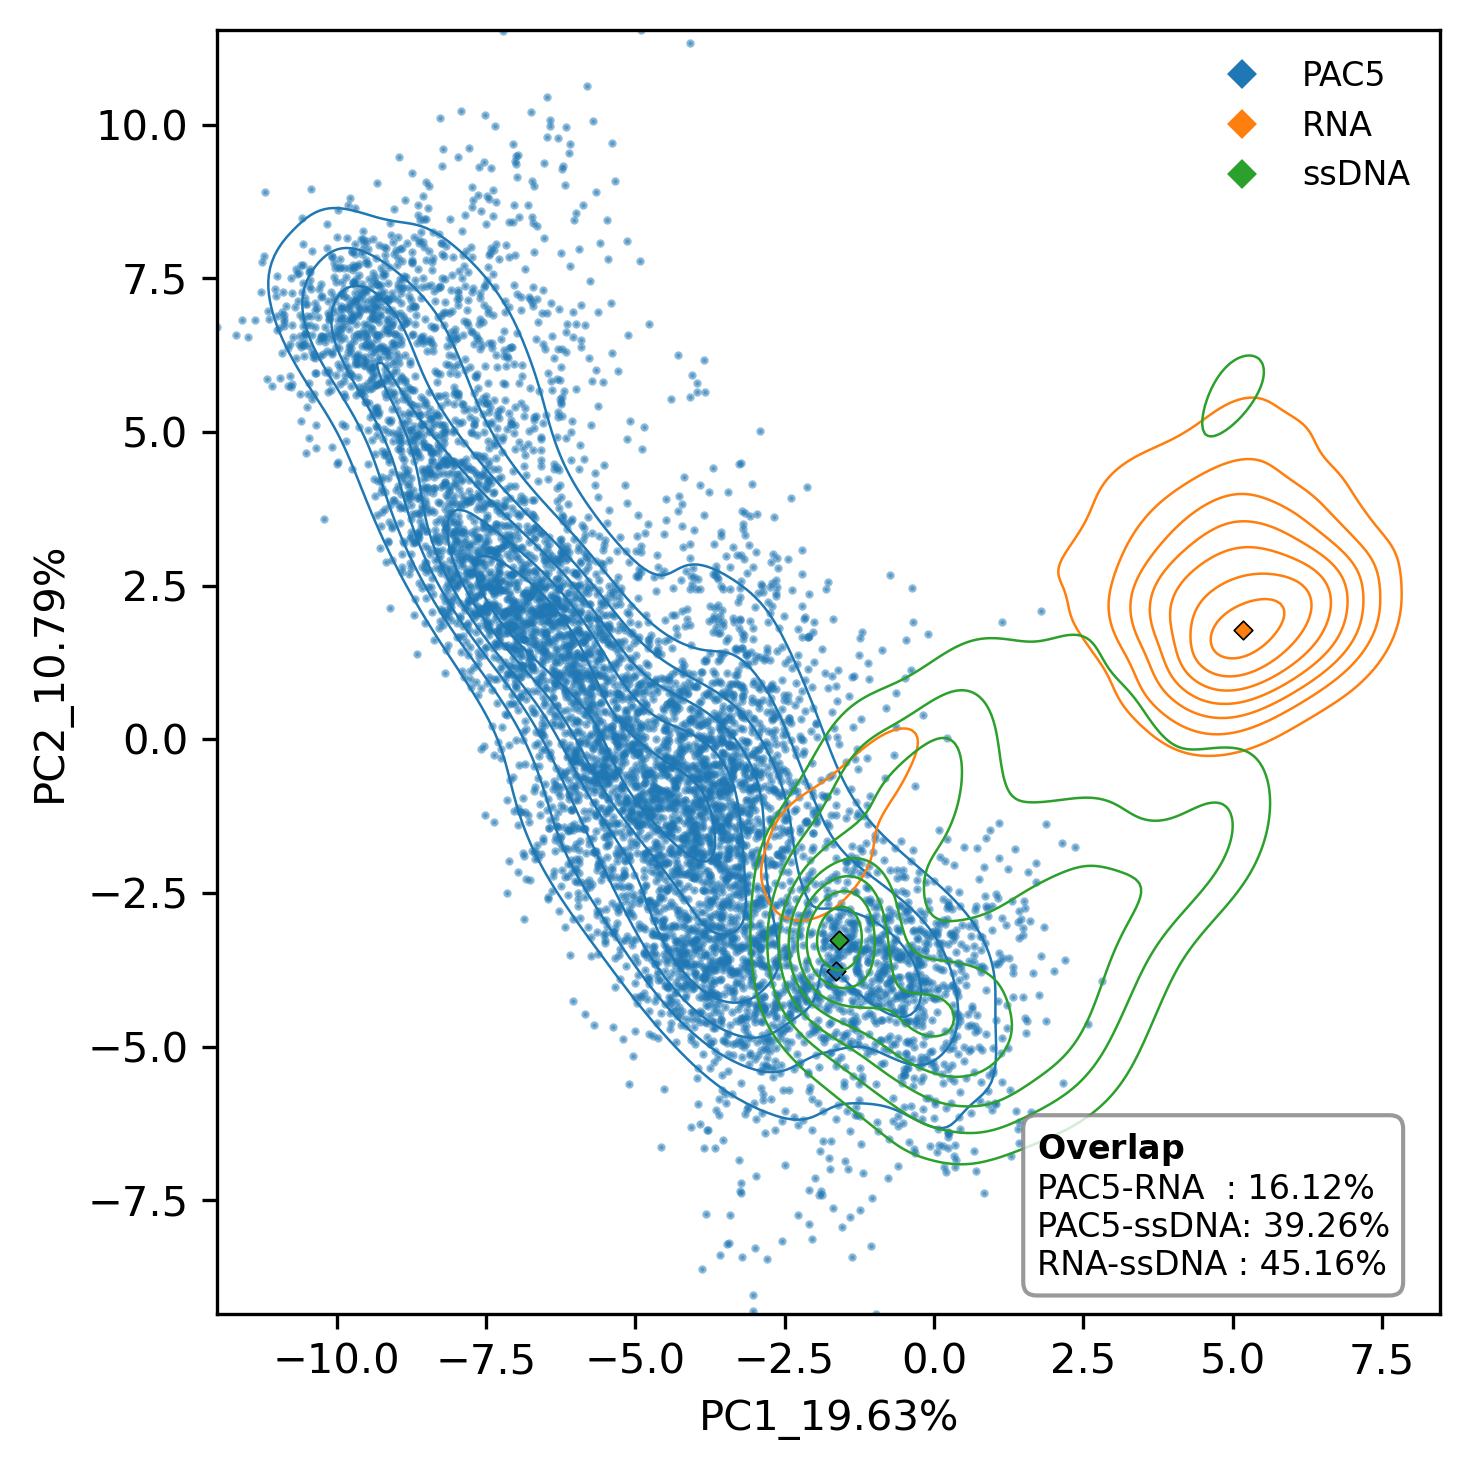

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
import numpy as np
import os

colors = {'PAC5':'tab:blue', 'RNA':'tab:orange', 'ssDNA':'tab:green'}
fig, ax = plt.subplots(figsize=(5,5), dpi=300)

for name, pts in zip(['PAC5','RNA','ssDNA'],
                     [pca_PAC5, pca_RNA, pca_ssDNA]):
    kde = gaussian_kde(pts.T, bw_method='scott')
    xmin,xmax = pts[:,0].min(), pts[:,0].max()
    ymin,ymax = pts[:,1].min(), pts[:,1].max()
    xi,yi = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    ax.contour(xi, yi, zi, levels=8, colors=colors[name], linewidths=0.6)
    if name=='PAC5':   # 原散点
        ax.scatter(*pts.T, s=1, alpha=0.5, c=colors[name], label=name)


for name in ['PAC5','RNA','ssDNA']:
    pts = picked_coords[name]
    # 统一用菱形
    ax.scatter(pts[0], pts[1], marker='D', s=10,
               c=colors[name], edgecolors='black', linewidths=0.4)

custom = [Line2D([0],[0], marker='D', color=colors[n], linestyle='None', markersize=4)
          for n in ['PAC5','RNA','ssDNA']]
ax.legend(custom, ['PAC5','RNA','ssDNA'],
          loc='upper right', frameon=False, fontsize=8)


textstr = "\n".join([r"$\bf{Overlap}$",
                     f"PAC5-RNA  : {ov_PR*100:.2f}%",
                     f"PAC5-ssDNA: {ov_PS*100:.2f}%",
                     f"RNA-ssDNA : {ov_RS*100:.2f}%"])
ax.text(0.67, 0.03, textstr, transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel(f'PC1_{PCA_ratio[0]}%'); ax.set_ylabel(f'PC2_{PCA_ratio[1]}%')
plt.tight_layout()

plt.savefig("../Pics/RRM1_PCA.svg")
plt.savefig("../Pics/RRM1_PCA.png", dpi=300)

plt.show()